## Imports and Setup

In [1]:
import os
import random
import warnings
import numpy as np
import polars as pl
import scipy
import sklearn
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import plotly.io as pio

pio.renderers.default = "png"
pio.kaleido.scope.default_scale = 2

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"numpy       {np.__version__}")
print(f"polars      {pl.__version__}")
print(f"scipy       {scipy.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"plotly      {plotly.__version__}")

numpy       2.5.2
polars      1.43.2
scipy       1.18.0
scikit-learn 1.9.0
plotly      6.9.0


/var/folders/cz/x56wj7xx759590kg8s44wshm0000gn/T/ipykernel_89543/1297777349.py:18: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_scale instead.

  pio.kaleido.scope.default_scale = 2


## Loading Processed Data

In [2]:
PROCESSED_DATA_DIR = "../data/processed"

X_train = pl.read_parquet(f"{PROCESSED_DATA_DIR}/X_train.parquet")
X_test = pl.read_parquet(f"{PROCESSED_DATA_DIR}/X_test.parquet")
y_train = pl.read_parquet(f"{PROCESSED_DATA_DIR}/y_train.parquet")
y_test = pl.read_parquet(f"{PROCESSED_DATA_DIR}/y_test.parquet")

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (137, 26), X_test: (68, 26)
y_train: (137, 1), y_test: (68, 1)


## Checking symboling Dtype After Parquet Round Trip

In [3]:
X_train["symboling"].dtype

Enum(categories=['-3', '-2', '-1', '0', '1', '2', '3'])

## Inspecting model Values

In [4]:
sorted(X_train["model"].unique().to_list())

['',
 '100 ls',
 '100ls',
 '1131 deluxe sedan',
 '12tl',
 '144ea',
 '145e (sw)',
 '244dl',
 '245',
 '246',
 '264gl',
 '304',
 '320i',
 '4000',
 '411 (sw)',
 '5 gtl',
 '5000',
 '504',
 '504 (sw)',
 '505s turbo diesel',
 '604sl',
 '626',
 '99e',
 '99gle',
 '99le',
 'accord',
 'accord cvcc',
 'brz',
 'carina',
 'cayenne',
 'celica gt liftback',
 'challenger se',
 'civic',
 'civic (auto)',
 'civic 1500 gl',
 'civic cvcc',
 'clipper',
 'colt (sw)',
 'corolla',
 'corolla 1200',
 'corolla liftback',
 'corolla tercel',
 'corona',
 'corona mark ii',
 'coronet custom',
 'cressida',
 'cricket',
 'd-max ',
 'd200',
 'dart custom',
 'dasher',
 'diesel',
 'dl',
 'duster',
 'fuga',
 'fury gran sedan',
 'fury iii',
 'g4',
 'giulia',
 'glc 4',
 'glc custom',
 'glc deluxe',
 'kicks',
 'lancer',
 'latio',
 'leaf',
 'macan',
 'mark ii',
 'mirage g4',
 'model 111',
 'montero',
 'mu-x',
 'opel isuzu deluxe',
 'otti',
 'outlander',
 'panamera',
 'prelude',
 'quadrifoglio',
 'rabbit',
 'rabbit custom',
 'ramp

## Checking the Empty Model Value

In [5]:
X_train.filter(pl.col("model") == "").select("brand", "model")

brand,model
str,str
"""subaru""",""""""
"""subaru""",""""""


## Dropping model

In [6]:
X_train = X_train.drop("model")
X_test = X_test.drop("model")

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (137, 25), X_test: (68, 25)


## Checking Skewed Columns for Transform Feasibility

In [7]:
skew_check_cols = ["price", "compressionratio", "enginesize", "horsepower", "wheelbase"]

check = pl.DataFrame({
    "column": skew_check_cols,
    "skew": [X_train[col].skew() if col != "price" else y_train["price"].skew() for col in skew_check_cols],
    "min": [X_train[col].min() if col != "price" else y_train["price"].min() for col in skew_check_cols],
})

check

column,skew,min
str,f64,f64
"""price""",1.676218,5118.0
"""compressionratio""",2.937803,7.0
"""enginesize""",2.104959,70.0
"""horsepower""",1.578011,52.0
"""wheelbase""",1.083146,88.6


## Comparing Skew Before and After Log Transform

In [8]:
log_candidates = ["enginesize", "horsepower", "wheelbase"]

skew_compare = pl.DataFrame({
    "column": log_candidates + ["price"],
    "skew_before": [X_train[col].skew() for col in log_candidates] + [y_train["price"].skew()],
    "skew_after_log": [X_train[col].log().skew() for col in log_candidates] + [y_train["price"].log().skew()],
})

skew_compare

column,skew_before,skew_after_log
str,f64,f64
"""enginesize""",2.104959,1.078778
"""horsepower""",1.578011,0.596953
"""wheelbase""",1.083146,0.962831
"""price""",1.676218,0.567851


## Testing Box-Cox on enginesize and wheelbase

In [9]:
from scipy.stats import boxcox

enginesize_bc, enginesize_lambda = boxcox(X_train["enginesize"].to_numpy())
wheelbase_bc, wheelbase_lambda = boxcox(X_train["wheelbase"].to_numpy())

import scipy.stats as stats

boxcox_compare = pl.DataFrame({
    "column": ["enginesize", "wheelbase"],
    "skew_after_log": [X_train["enginesize"].log().skew(), X_train["wheelbase"].log().skew()],
    "skew_after_boxcox": [float(stats.skew(enginesize_bc)), float(stats.skew(wheelbase_bc))],
    "boxcox_lambda": [enginesize_lambda, wheelbase_lambda],
})

boxcox_compare

column,skew_after_log,skew_after_boxcox,boxcox_lambda
str,f64,f64,f64
"""enginesize""",1.078778,0.048716,-1.359662
"""wheelbase""",0.962831,0.041315,-6.80543


## Applying Log and Box-Cox Transforms

In [10]:
from scipy.stats import boxcox

log_cols = ["horsepower", "wheelbase"]

for col in log_cols:
    X_train = X_train.with_columns(X_train[col].log().alias(f"{col}_log"))
    X_test = X_test.with_columns(X_test[col].log().alias(f"{col}_log"))

y_train = y_train.with_columns(y_train["price"].log().alias("price_log"))
y_test = y_test.with_columns(y_test["price"].log().alias("price_log"))

enginesize_boxcox_train, ENGINESIZE_LAMBDA = boxcox(X_train["enginesize"].to_numpy())
X_train = X_train.with_columns(pl.Series("enginesize_boxcox", enginesize_boxcox_train))

enginesize_boxcox_test = boxcox(X_test["enginesize"].to_numpy(), lmbda=ENGINESIZE_LAMBDA)
X_test = X_test.with_columns(pl.Series("enginesize_boxcox", enginesize_boxcox_test))

print(f"ENGINESIZE_LAMBDA: {ENGINESIZE_LAMBDA:.4f}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

ENGINESIZE_LAMBDA: -1.3597
X_train: (137, 28), X_test: (68, 28)
y_train: (137, 2), y_test: (68, 2)


## Visualizing Transformed Distributions

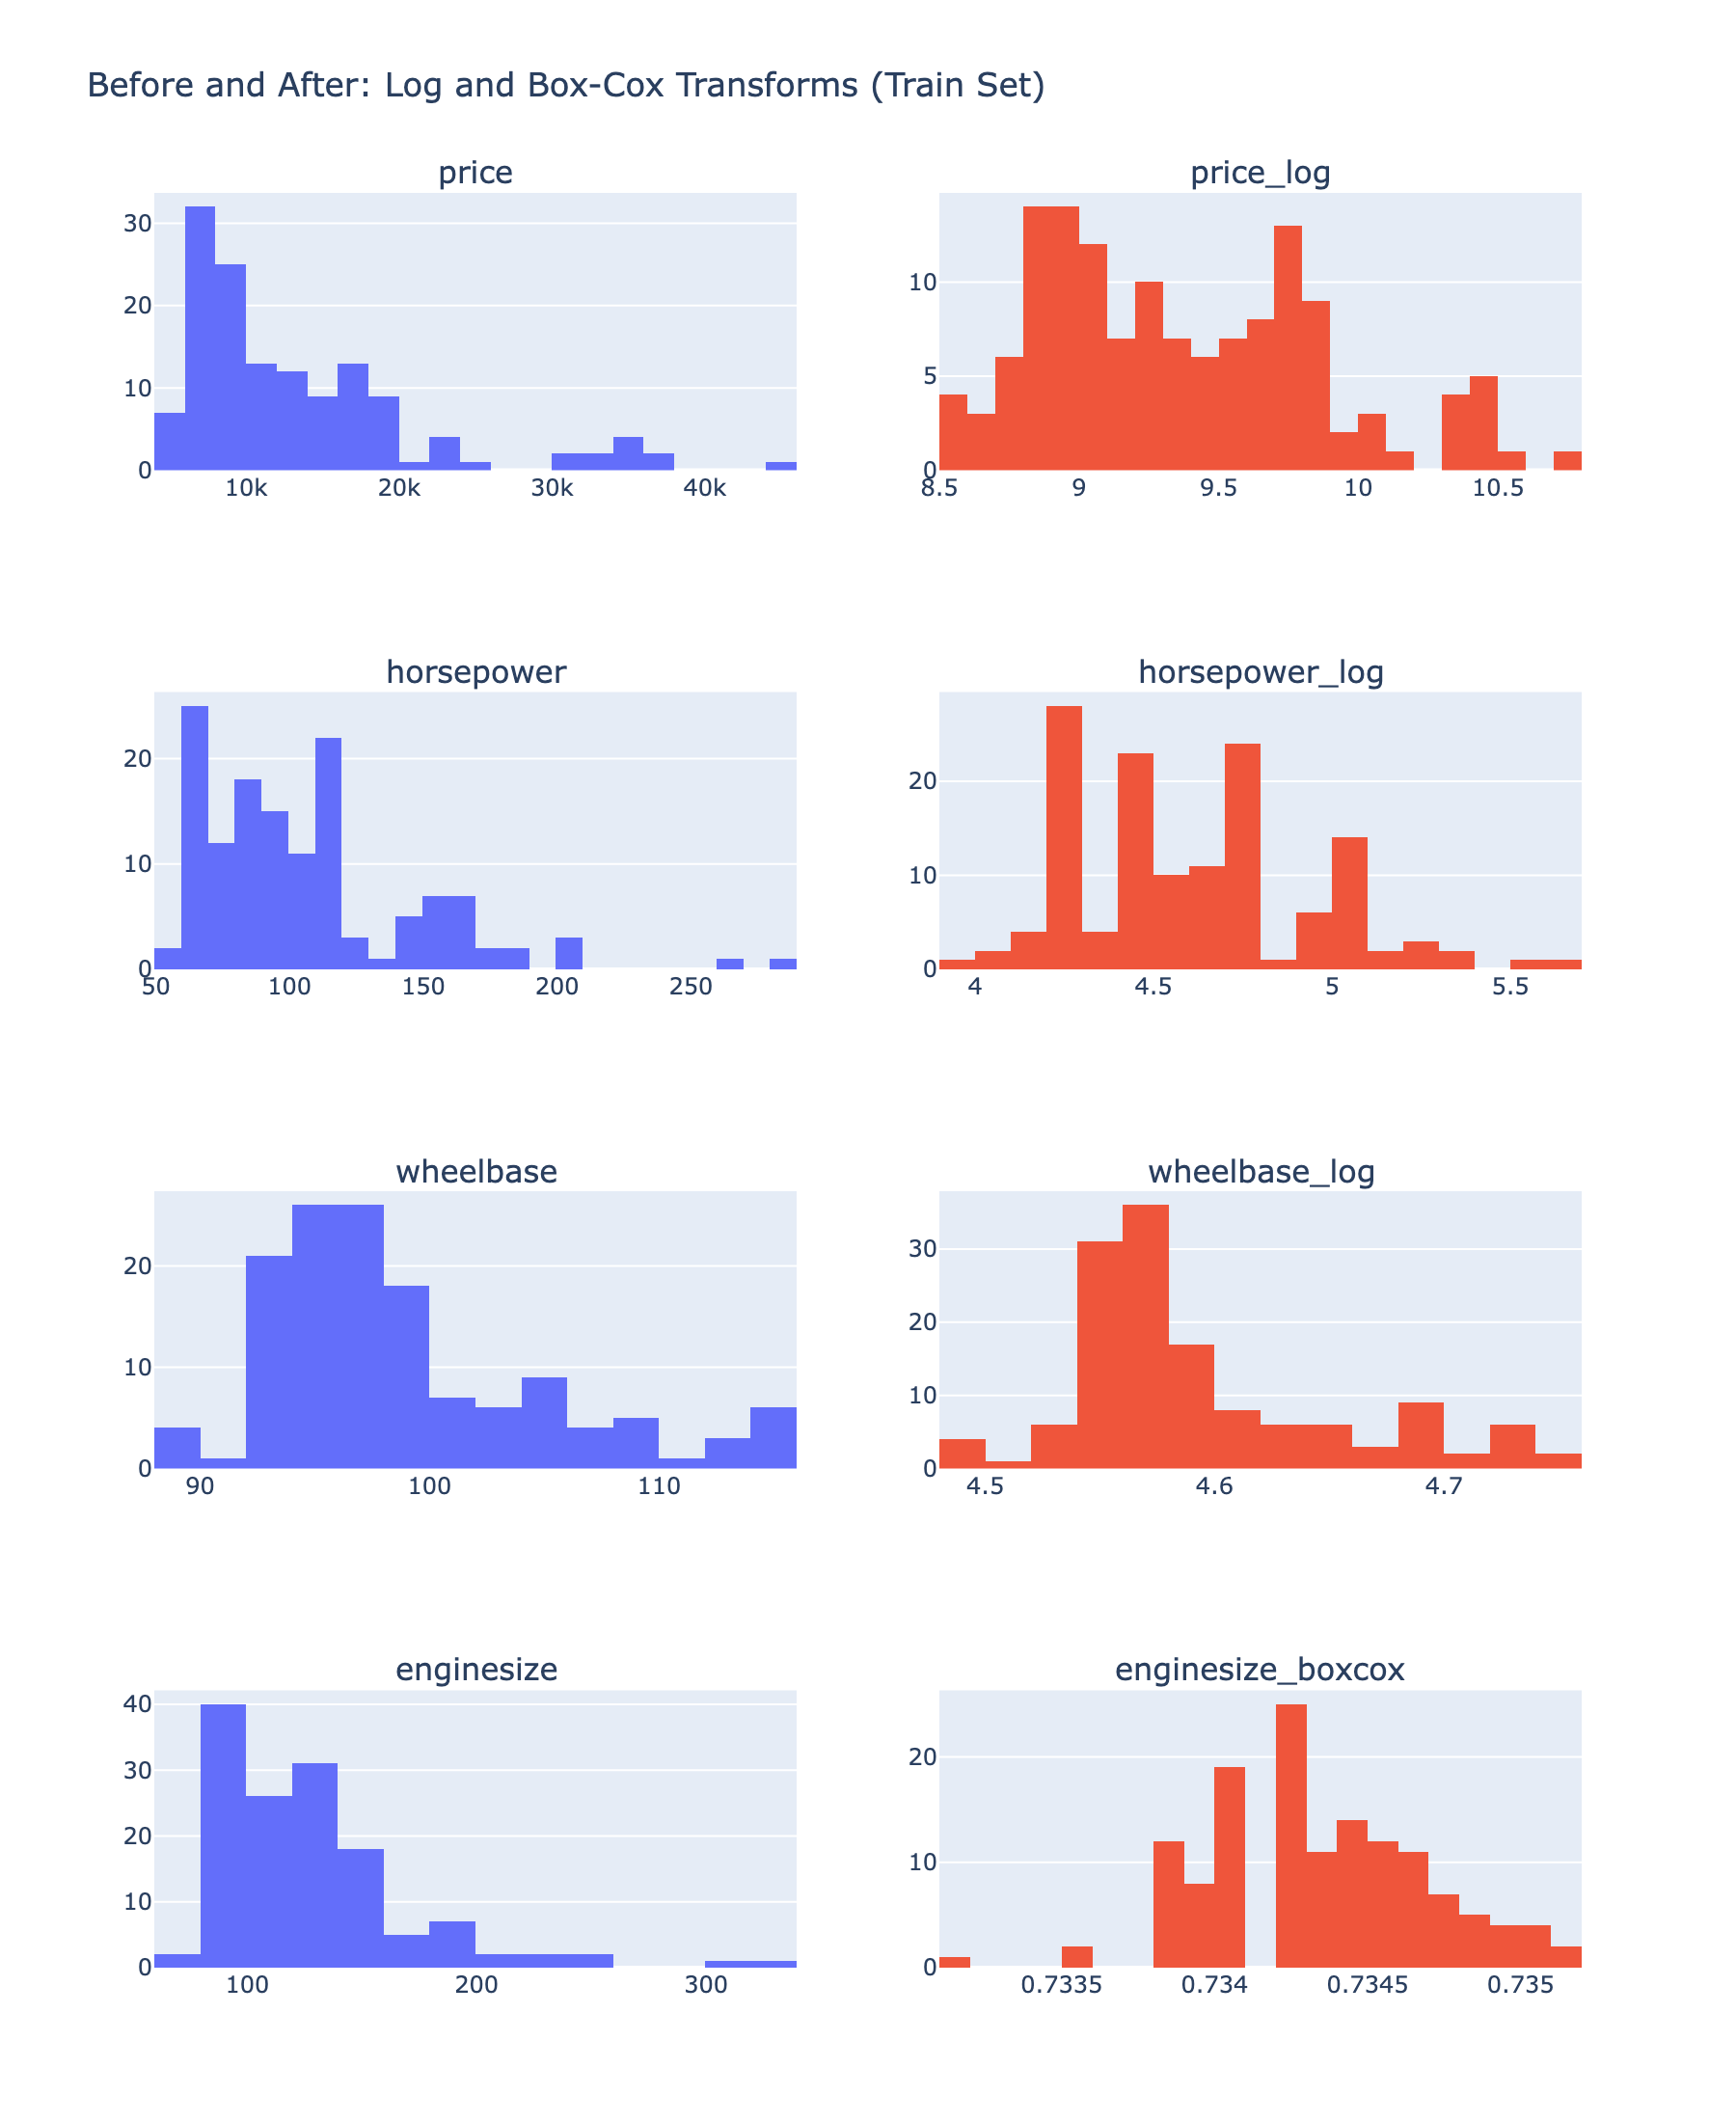

In [11]:
transform_pairs = [
    ("price", "price_log", y_train),
    ("horsepower", "horsepower_log", X_train),
    ("wheelbase", "wheelbase_log", X_train),
    ("enginesize", "enginesize_boxcox", X_train),
]

fig = make_subplots(
    rows=4, cols=2,
    subplot_titles=[t for pair in transform_pairs for t in (pair[0], pair[1])]
)

for i, (orig_col, trans_col, source_df) in enumerate(transform_pairs):
    row = i + 1
    fig.add_trace(
        go.Histogram(x=source_df[orig_col], nbinsx=25, marker_color="#636EFA", showlegend=False),
        row=row, col=1
    )
    fig.add_trace(
        go.Histogram(x=source_df[trans_col], nbinsx=25, marker_color="#EF553B", showlegend=False),
        row=row, col=2
    )

fig.update_layout(
    title="Before and After: Log and Box-Cox Transforms (Train Set)",
    height=1100,
    width=900
)

fig.write_image("../reports/figures/11_transform_before_after.png")
fig.show()

## Checking enginesize_boxcox Value Spread

In [12]:
X_train.select("enginesize", "enginesize_boxcox").describe()

statistic,enginesize,enginesize_boxcox
str,f64,f64
"""count""",137.0,137.0
"""null_count""",0.0,0.0
"""mean""",127.321168,0.734338
"""std""",41.964259,0.000366
"""min""",70.0,0.733197
"""25%""",98.0,0.734034
"""50%""",120.0,0.734381
"""75%""",141.0,0.734597
"""max""",326.0,0.735195


## Replacing enginesize_boxcox with enginesize_log

In [13]:
X_train = X_train.drop("enginesize_boxcox")
X_test = X_test.drop("enginesize_boxcox")

X_train = X_train.with_columns(X_train["enginesize"].log().alias("enginesize_log"))
X_test = X_test.with_columns(X_test["enginesize"].log().alias("enginesize_log"))

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (137, 28), X_test: (68, 28)


## Re-Visualizing Transformed Distributions

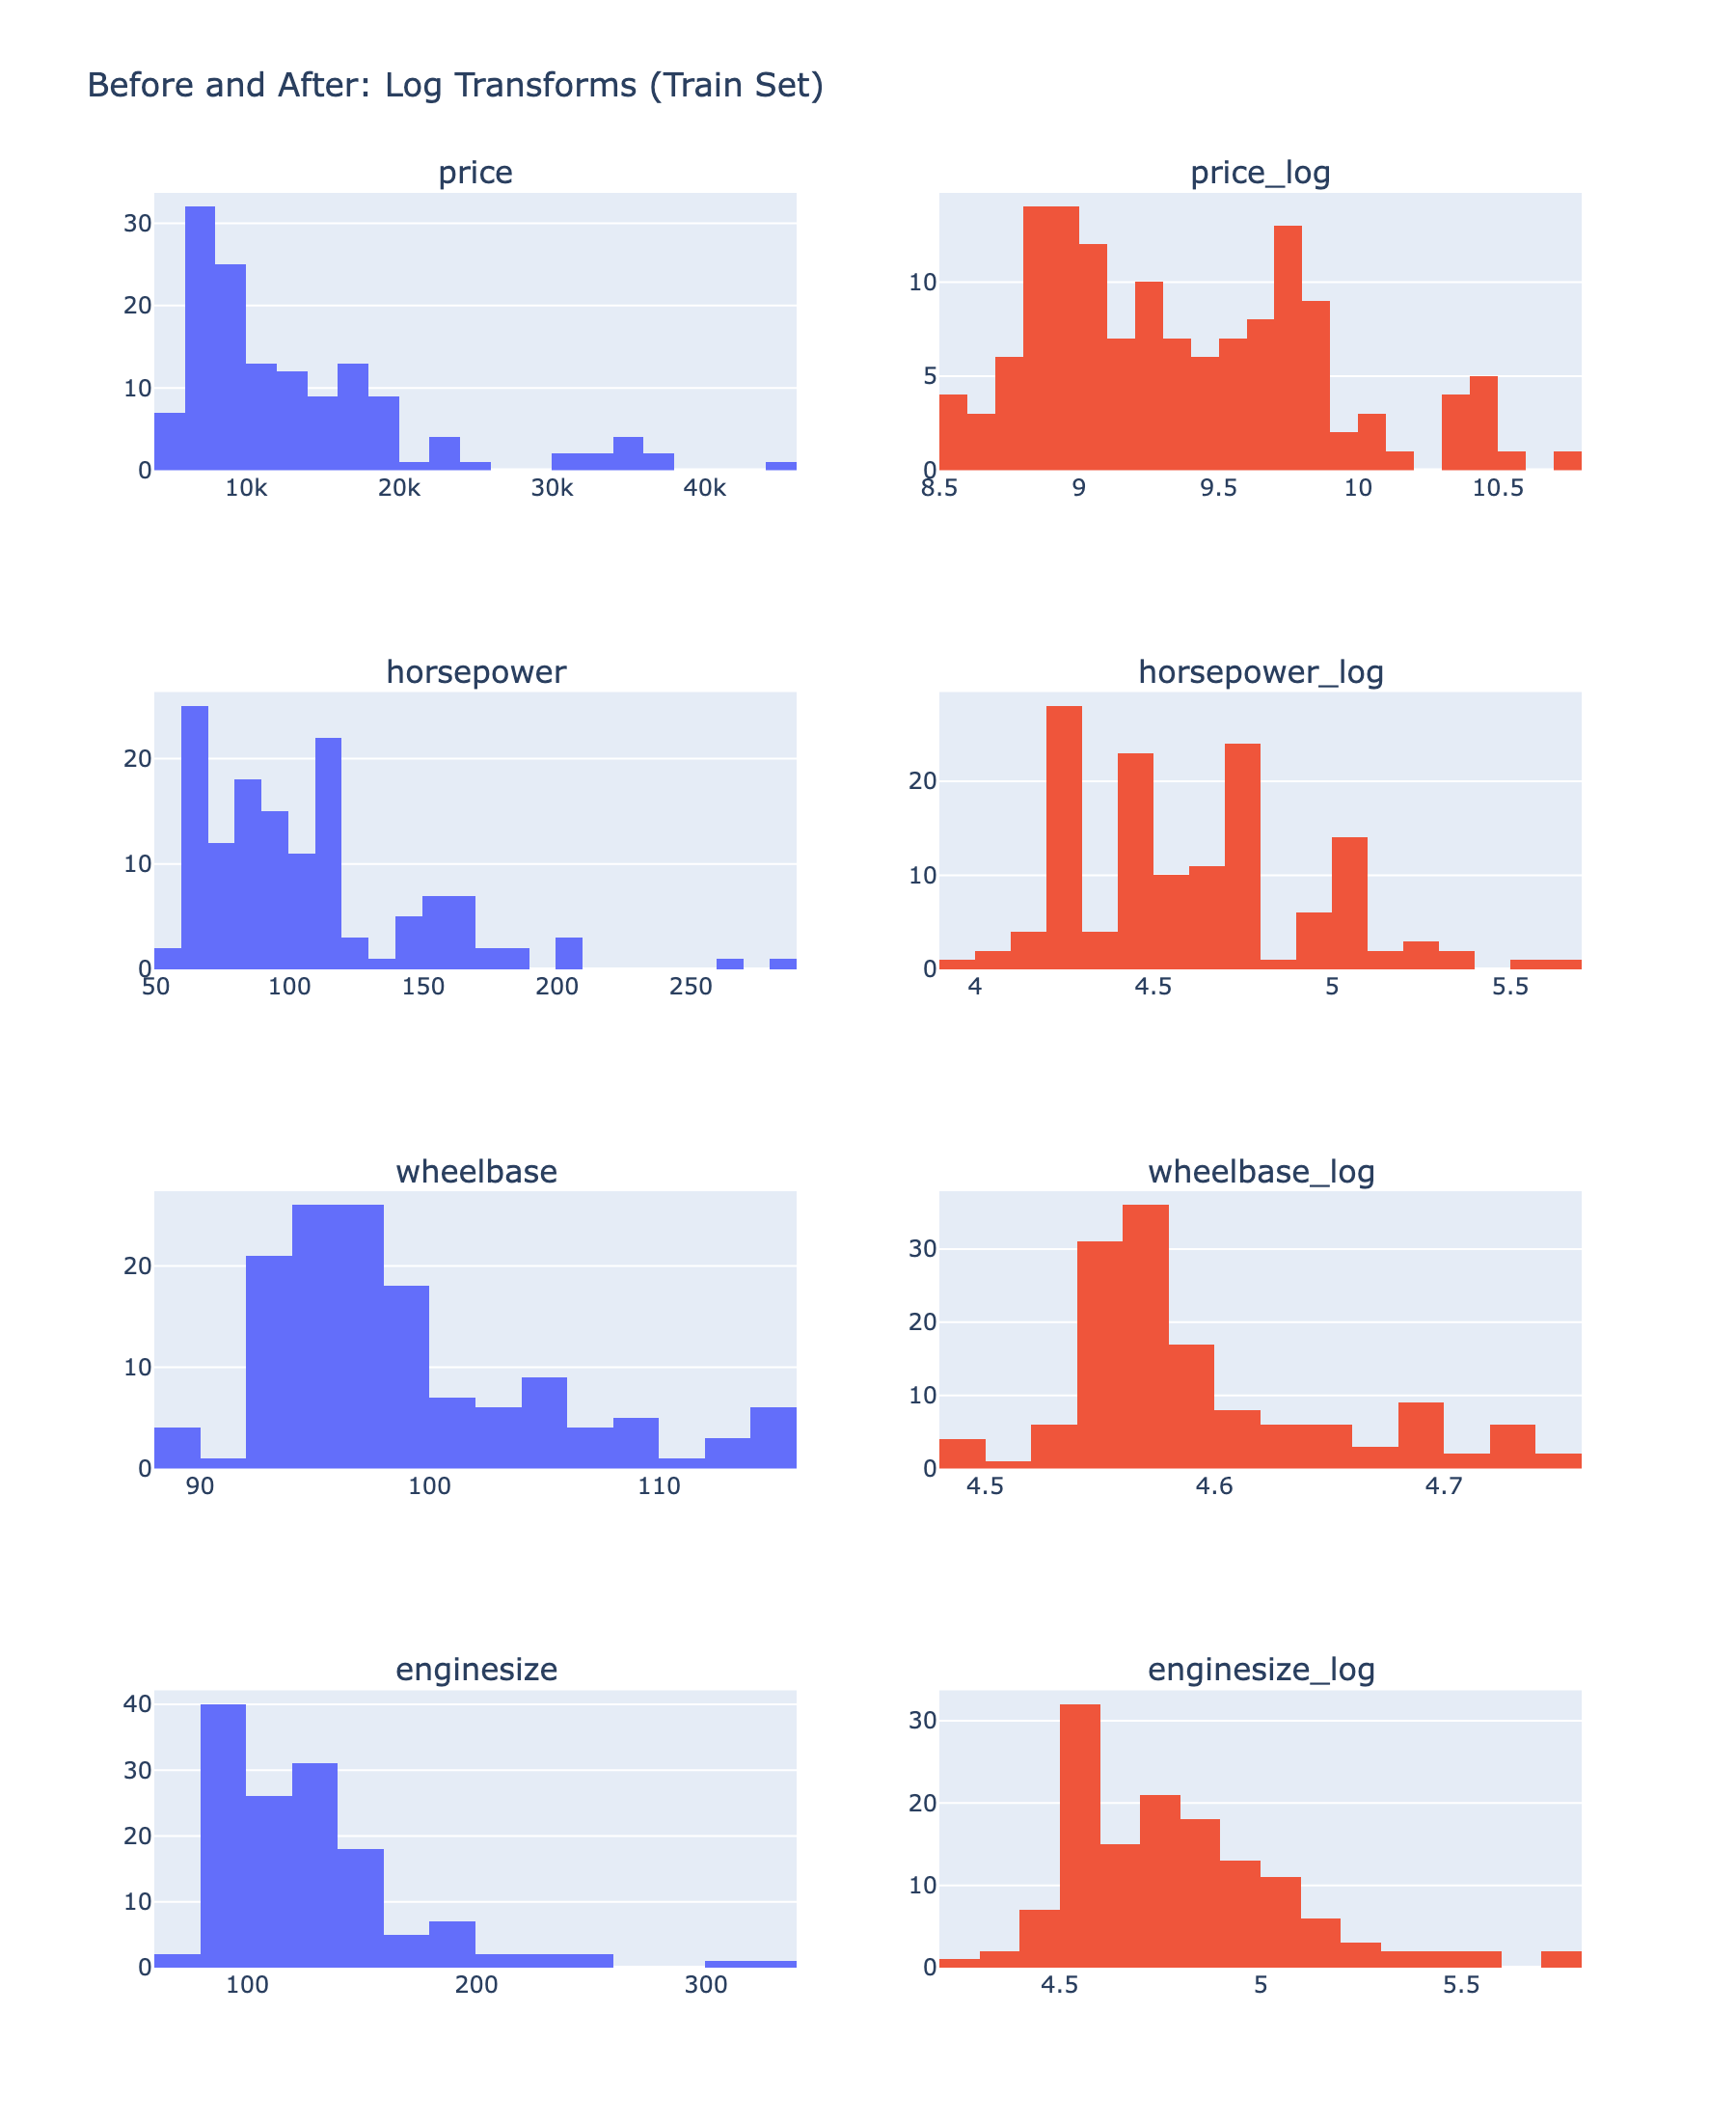

In [14]:
transform_pairs = [
    ("price", "price_log", y_train),
    ("horsepower", "horsepower_log", X_train),
    ("wheelbase", "wheelbase_log", X_train),
    ("enginesize", "enginesize_log", X_train),
]

fig = make_subplots(
    rows=4, cols=2,
    subplot_titles=[t for pair in transform_pairs for t in (pair[0], pair[1])]
)

for i, (orig_col, trans_col, source_df) in enumerate(transform_pairs):
    row = i + 1
    fig.add_trace(
        go.Histogram(x=source_df[orig_col], nbinsx=25, marker_color="#636EFA", showlegend=False),
        row=row, col=1
    )
    fig.add_trace(
        go.Histogram(x=source_df[trans_col], nbinsx=25, marker_color="#EF553B", showlegend=False),
        row=row, col=2
    )

fig.update_layout(
    title="Before and After: Log Transforms (Train Set)",
    height=1100,
    width=900
)

fig.write_image("../reports/figures/11_transform_before_after.png")
fig.show()

## Checking enginesize_log Value Spread

In [15]:
X_train.select("enginesize", "enginesize_log").describe()

statistic,enginesize,enginesize_log
str,f64,f64
"""count""",137.0,137.0
"""null_count""",0.0,0.0
"""mean""",127.321168,4.804618
"""std""",41.964259,0.276766
"""min""",70.0,4.248495
"""25%""",98.0,4.584967
"""50%""",120.0,4.787492
"""75%""",141.0,4.94876
"""max""",326.0,5.786897


## Engineering power_to_weight

In [17]:
X_train = X_train.with_columns(
    (pl.col("horsepower") / pl.col("curbweight")).alias("power_to_weight")
)
X_test = X_test.with_columns(
    (pl.col("horsepower") / pl.col("curbweight")).alias("power_to_weight")
)

X_train.select("horsepower", "curbweight", "power_to_weight").head(5)

horsepower,curbweight,power_to_weight
i64,i64,f64
143,2778,0.051476
100,2293,0.043611
70,2081,0.033638
160,2808,0.05698
73,2240,0.032589


## Checking power_to_weight Distribution and Price Correlation

In [18]:
pw_skew = X_train["power_to_weight"].skew()
pw_corr = X_train["power_to_weight"].to_frame().with_columns(y_train["price"]).corr()["price"][0]

print(f"power_to_weight skew: {pw_skew:.4f}")
print(f"power_to_weight correlation with price: {pw_corr:.4f}")

power_to_weight skew: 1.5233
power_to_weight correlation with price: 0.5328


## Comparing power_to_weight to horsepower's Correlation Strength

In [19]:
compare_corr = X_train.select("horsepower", "curbweight", "power_to_weight").with_columns(
    y_train["price"]
).corr()["price"]

print(compare_corr)

print(f"\nNull count: {X_train['power_to_weight'].null_count()}")
print(f"Infinite count: {X_train.filter(pl.col('power_to_weight').is_infinite()).height}")

shape: (4,)
Series: 'price' [f64]
[
	0.81447
	0.839053
	0.53277
	1.0
]

Null count: 0
Infinite count: 0


## Applying Log Transform to power_to_weight

In [20]:
X_train = X_train.with_columns(X_train["power_to_weight"].log().alias("power_to_weight_log"))
X_test = X_test.with_columns(X_test["power_to_weight"].log().alias("power_to_weight_log"))

print(f"power_to_weight_log skew: {X_train['power_to_weight_log'].skew():.4f}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

power_to_weight_log skew: 0.4332
X_train: (137, 30), X_test: (68, 30)


## Engineering wheelbase_to_length_ratio

In [21]:
X_train = X_train.with_columns(
    (pl.col("wheelbase") / pl.col("carlength")).alias("wheelbase_to_length_ratio")
)
X_test = X_test.with_columns(
    (pl.col("wheelbase") / pl.col("carlength")).alias("wheelbase_to_length_ratio")
)

X_train.select("wheelbase", "carlength", "wheelbase_to_length_ratio").head(5)

wheelbase,carlength,wheelbase_to_length_ratio
f64,f64,f64
94.5,168.9,0.559503
96.5,169.1,0.570668
95.7,166.3,0.575466
99.1,186.6,0.531083
93.3,157.3,0.593134


## Checking wheelbase_to_length_ratio Distribution and Price Correlation

In [22]:
wl_skew = X_train["wheelbase_to_length_ratio"].skew()
wl_corr = X_train["wheelbase_to_length_ratio"].to_frame().with_columns(y_train["price"]).corr()["price"][0]

print(f"wheelbase_to_length_ratio skew: {wl_skew:.4f}")
print(f"wheelbase_to_length_ratio correlation with price: {wl_corr:.4f}")

print(f"\nNull count: {X_train['wheelbase_to_length_ratio'].null_count()}")
print(f"Infinite count: {X_train.filter(pl.col('wheelbase_to_length_ratio').is_infinite()).height}")

wheelbase_to_length_ratio skew: 0.4462
wheelbase_to_length_ratio correlation with price: -0.4053

Null count: 0
Infinite count: 0


## Engineering car_volume

In [23]:
X_train = X_train.with_columns(
    (pl.col("carlength") * pl.col("carwidth") * pl.col("carheight")).alias("car_volume")
)
X_test = X_test.with_columns(
    (pl.col("carlength") * pl.col("carwidth") * pl.col("carheight")).alias("car_volume")
)

X_train.select("carlength", "carwidth", "carheight", "car_volume").head(5)

carlength,carwidth,carheight,car_volume
f64,f64,f64,f64
168.9,68.3,50.2,579100.674
169.1,66.0,51.0,569190.6
166.3,64.4,53.0,567615.16
186.6,66.5,56.1,696139.29
157.3,63.8,55.7,558990.718


## Checking car_volume Distribution and Price Correlation

In [24]:
cv_skew = X_train["car_volume"].skew()
cv_corr = X_train["car_volume"].to_frame().with_columns(y_train["price"]).corr()["price"][0]

print(f"car_volume skew: {cv_skew:.4f}")
print(f"car_volume correlation with price: {cv_corr:.4f}")

print(f"\nNull count: {X_train['car_volume'].null_count()}")
print(f"Infinite count: {X_train.filter(pl.col('car_volume').is_infinite()).height}")

car_volume skew: 0.5747
car_volume correlation with price: 0.6020

Null count: 0
Infinite count: 0


## Comparing car_volume to Individual Dimension Correlations

In [25]:
compare_corr = X_train.select("carlength", "carwidth", "carheight", "car_volume").with_columns(
    y_train["price"]
).corr()["price"]

print(compare_corr)

shape: (5,)
Series: 'price' [f64]
[
	0.674851
	0.777868
	0.053864
	0.60204
	1.0
]


## Updated Correlation Heatmap

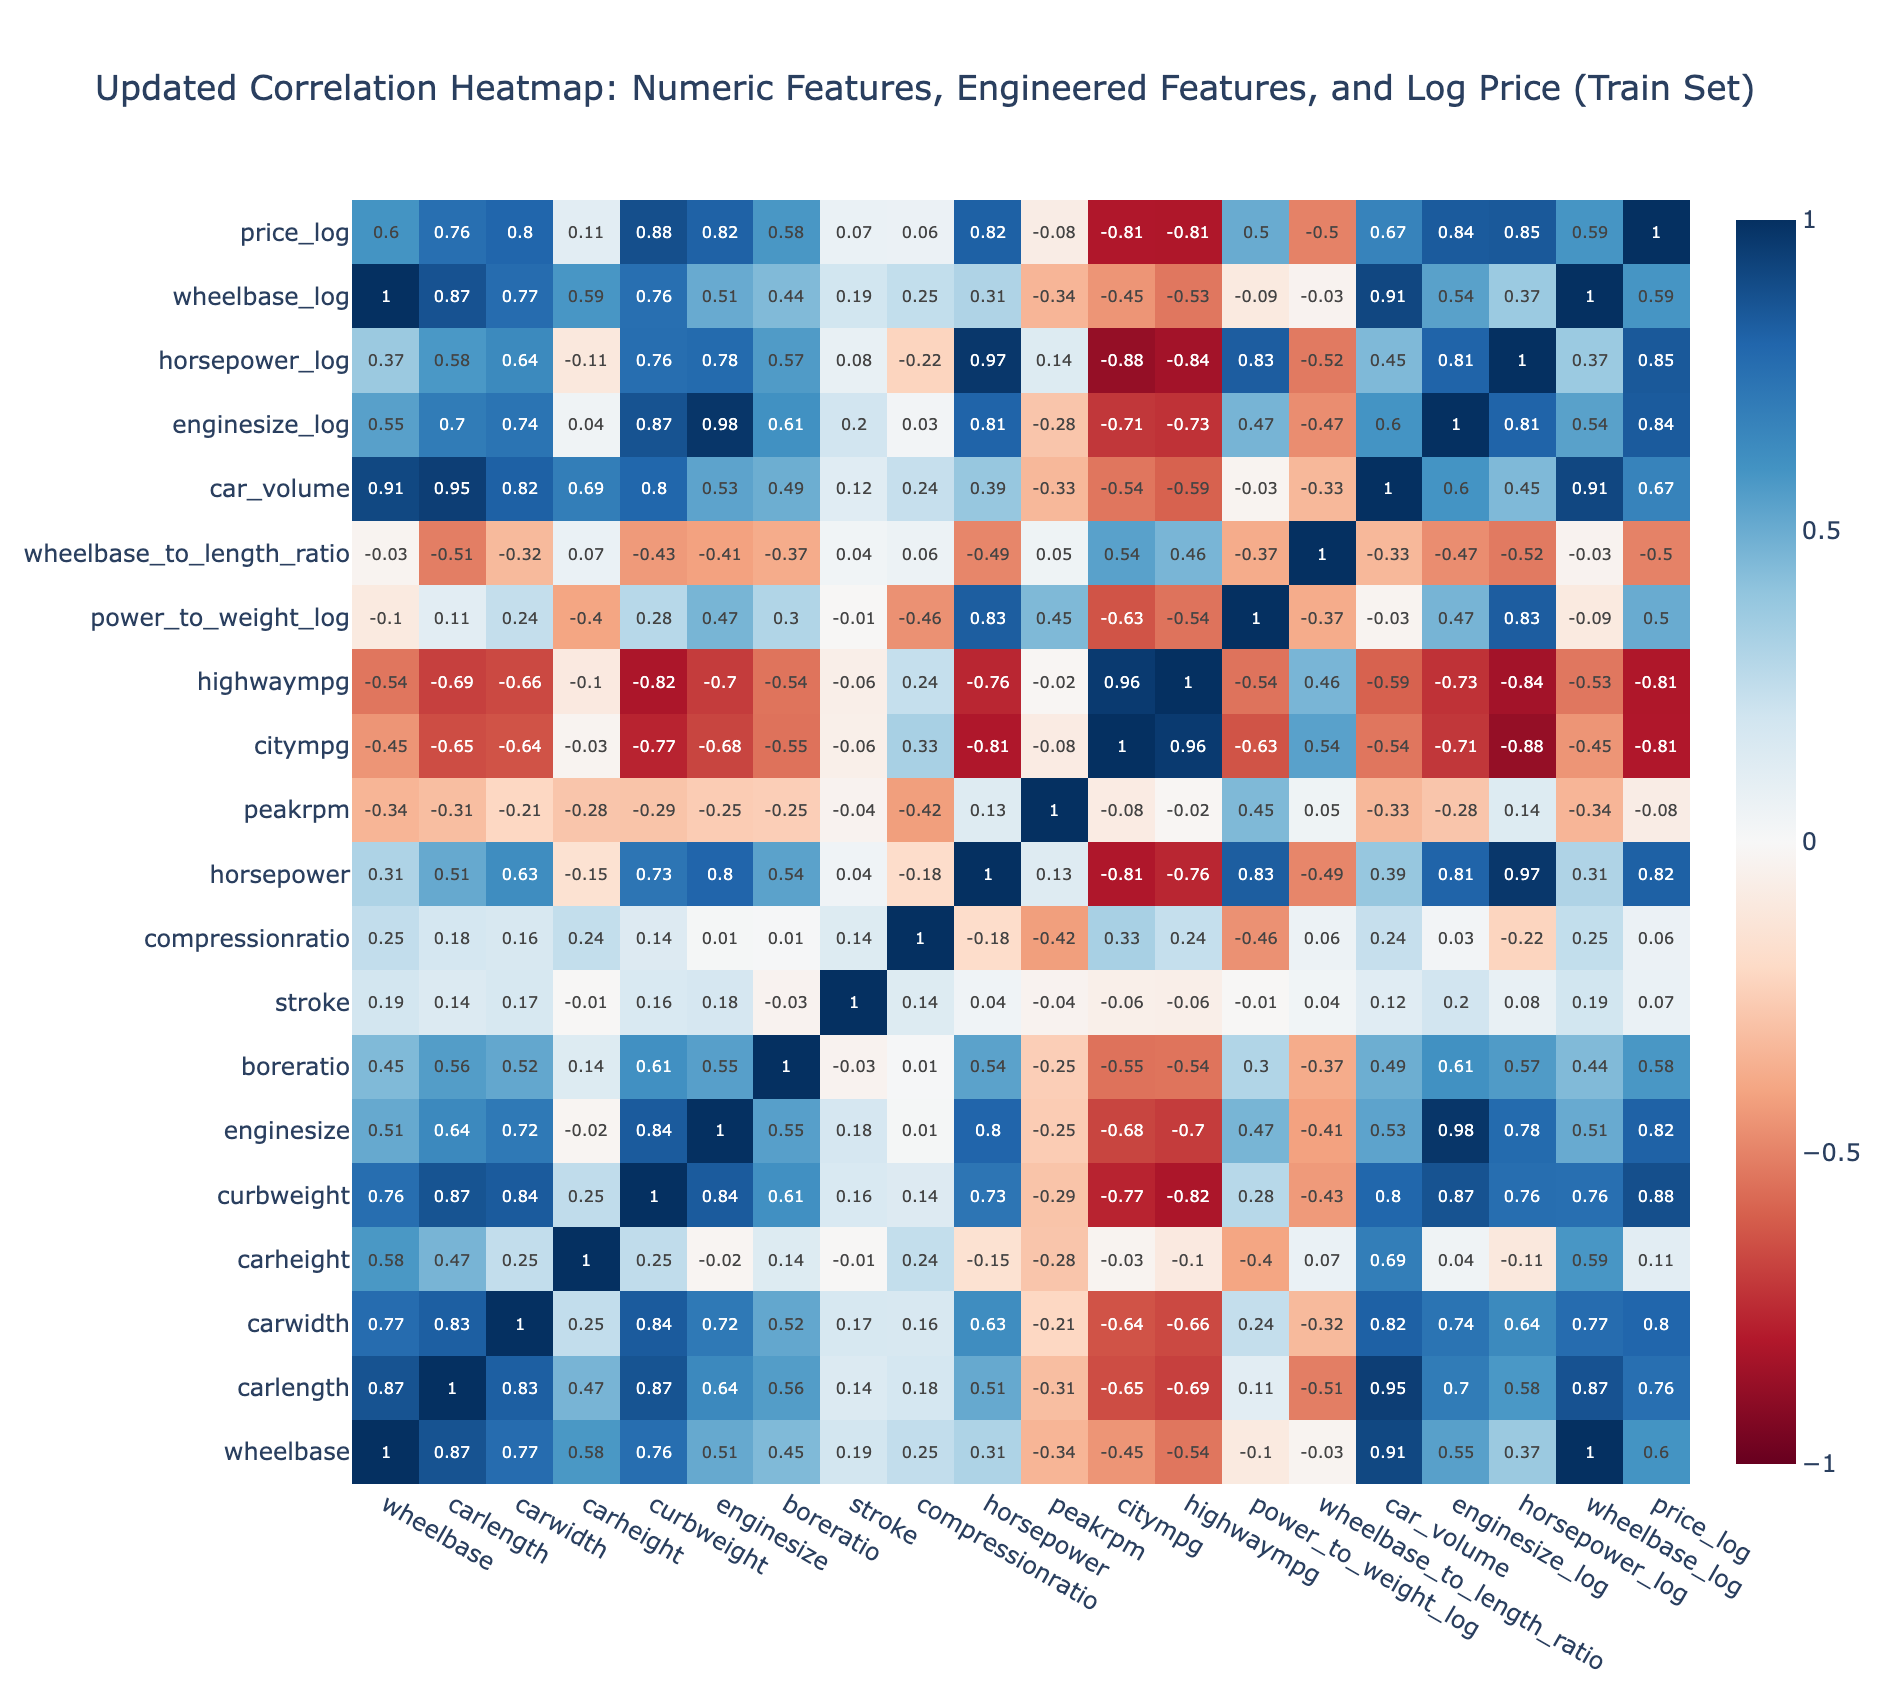

In [26]:
updated_numeric_cols = [
    "wheelbase", "carlength", "carwidth", "carheight", "curbweight",
    "enginesize", "boreratio", "stroke", "compressionratio",
    "horsepower", "peakrpm", "citympg", "highwaympg",
    "power_to_weight_log", "wheelbase_to_length_ratio", "car_volume",
    "enginesize_log", "horsepower_log", "wheelbase_log"
]

train_with_price = X_train.select(updated_numeric_cols).with_columns(y_train["price_log"])
corr_matrix_updated = train_with_price.to_pandas().corr()

fig = go.Figure(data=go.Heatmap(
    z=corr_matrix_updated.values,
    x=corr_matrix_updated.columns,
    y=corr_matrix_updated.columns,
    colorscale="RdBu",
    zmid=0,
    text=corr_matrix_updated.round(2).values,
    texttemplate="%{text}",
    textfont={"size": 8}
))

fig.update_layout(
    title="Updated Correlation Heatmap: Numeric Features, Engineered Features, and Log Price (Train Set)",
    height=850,
    width=950
)

fig.write_image("../reports/figures/12_updated_correlation_heatmap.png")
fig.show()

## Dropping Redundant Raw Columns

In [27]:
raw_cols_to_drop = ["enginesize", "horsepower", "wheelbase", "power_to_weight"]

X_train = X_train.drop(raw_cols_to_drop)
X_test = X_test.drop(raw_cols_to_drop)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (137, 28), X_test: (68, 28)


## Updated Correlation Heatmap (Cleaned Feature Set)

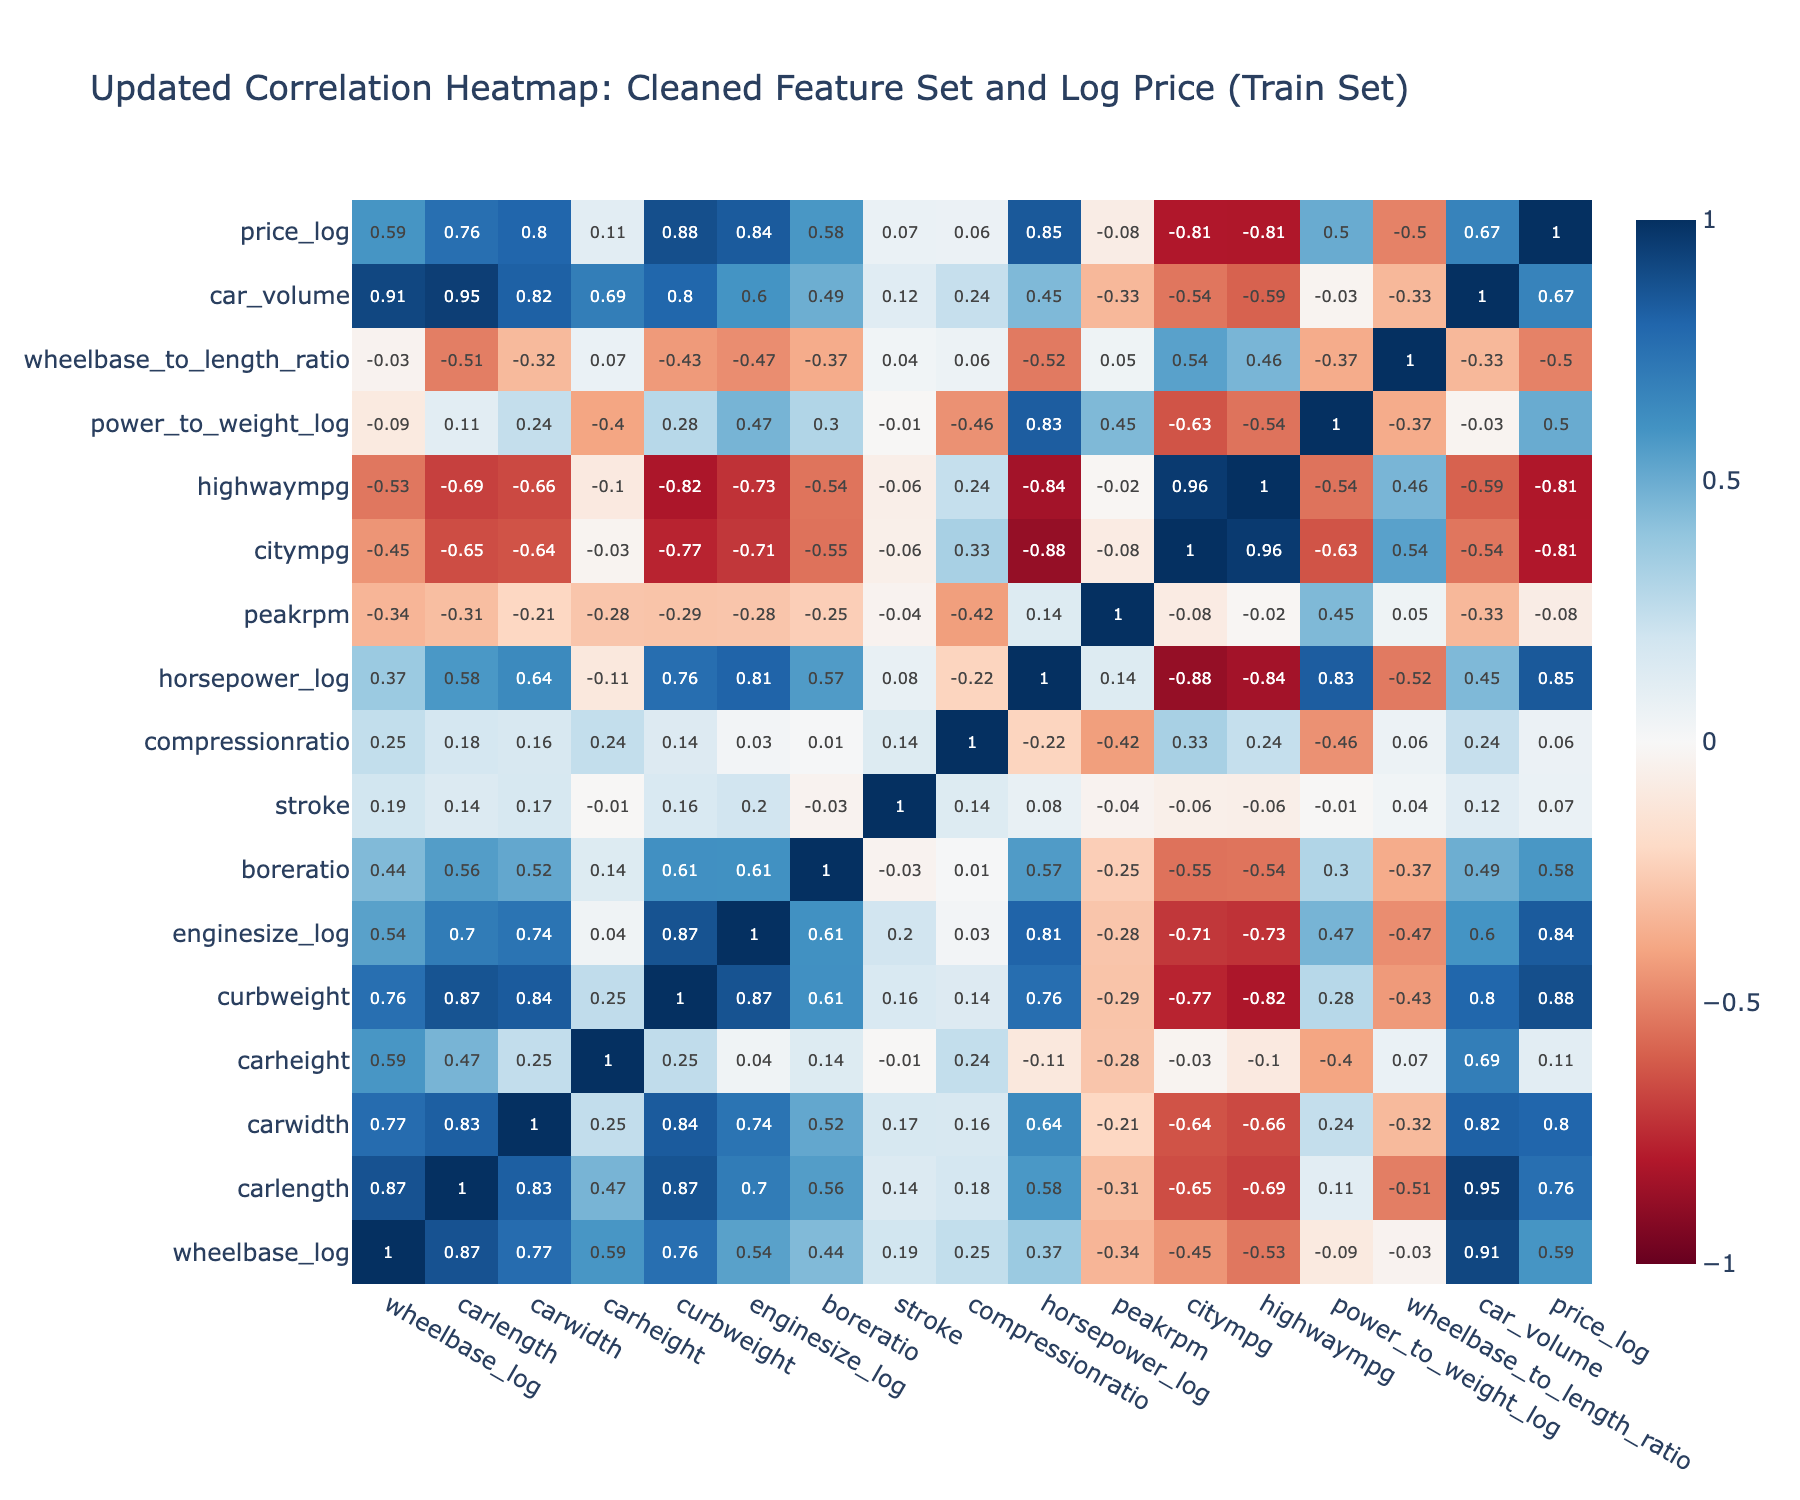

In [28]:
updated_numeric_cols = [
    "wheelbase_log", "carlength", "carwidth", "carheight", "curbweight",
    "enginesize_log", "boreratio", "stroke", "compressionratio",
    "horsepower_log", "peakrpm", "citympg", "highwaympg",
    "power_to_weight_log", "wheelbase_to_length_ratio", "car_volume"
]

train_with_price = X_train.select(updated_numeric_cols).with_columns(y_train["price_log"])
corr_matrix_updated = train_with_price.to_pandas().corr()

fig = go.Figure(data=go.Heatmap(
    z=corr_matrix_updated.values,
    x=corr_matrix_updated.columns,
    y=corr_matrix_updated.columns,
    colorscale="RdBu",
    zmid=0,
    text=corr_matrix_updated.round(2).values,
    texttemplate="%{text}",
    textfont={"size": 8}
))

fig.update_layout(
    title="Updated Correlation Heatmap: Cleaned Feature Set and Log Price (Train Set)",
    height=750,
    width=900
)

fig.write_image("../reports/figures/12_updated_correlation_heatmap.png")
fig.show()

## Updated VIF Table

In [29]:
vif_cols = updated_numeric_cols

X_vif = add_constant(X_train.select(vif_cols).to_pandas())

vif_data_updated = pl.DataFrame({
    "feature": vif_cols,
    "VIF": [
        variance_inflation_factor(X_vif.values, i + 1)
        for i in range(len(vif_cols))
    ]
}).sort("VIF", descending=True)

vif_data_updated

feature,VIF
str,f64
"""carlength""",3094.180914
"""car_volume""",1240.958616
"""wheelbase_log""",1159.66782
"""horsepower_log""",664.343901
"""wheelbase_to_length_ratio""",411.633708
…,…
"""enginesize_log""",8.982524
"""compressionratio""",2.440406
"""peakrpm""",2.391235


## Full VIF Table

In [30]:
pl.Config.set_tbl_rows(20)
vif_data_updated

feature,VIF
str,f64
"""carlength""",3094.180914
"""car_volume""",1240.958616
"""wheelbase_log""",1159.66782
"""horsepower_log""",664.343901
"""wheelbase_to_length_ratio""",411.633708
"""power_to_weight_log""",292.561463
"""curbweight""",224.031472
"""carheight""",152.937872
"""carwidth""",92.056668


## Dropping Engineered Features From Modeling Set

In [31]:
engineered_cols_to_drop = ["car_volume", "wheelbase_to_length_ratio", "power_to_weight_log"]

X_train = X_train.drop(engineered_cols_to_drop)
X_test = X_test.drop(engineered_cols_to_drop)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (137, 25), X_test: (68, 25)


## Final VIF Check on Modeling Feature Set

In [32]:
final_vif_cols = [
    "wheelbase_log", "carlength", "carwidth", "carheight", "curbweight",
    "enginesize_log", "boreratio", "stroke", "compressionratio",
    "horsepower_log", "peakrpm", "citympg", "highwaympg"
]

X_vif_final = add_constant(X_train.select(final_vif_cols).to_pandas())

vif_data_final = pl.DataFrame({
    "feature": final_vif_cols,
    "VIF": [
        variance_inflation_factor(X_vif_final.values, i + 1)
        for i in range(len(final_vif_cols))
    ]
}).sort("VIF", descending=True)

vif_data_final

feature,VIF
str,f64
"""citympg""",24.997455
"""highwaympg""",18.872175
"""curbweight""",15.556091
"""horsepower_log""",10.248417
"""carlength""",9.0904
"""enginesize_log""",8.132088
"""wheelbase_log""",8.07261
"""carwidth""",4.825082
"""peakrpm""",2.275686


## Checking cylindernumber Values After Rare Grouping

In [33]:
X_train["cylindernumber"].value_counts().sort("count", descending=True)

cylindernumber,count
str,u32
"""four""",109
"""six""",16
"""five""",5
"""eight""",4
"""two""",2
"""other""",1


## Encoding symboling as Ordinal

In [34]:
X_train = X_train.with_columns(pl.col("symboling").to_physical().alias("symboling_encoded"))
X_test = X_test.with_columns(pl.col("symboling").to_physical().alias("symboling_encoded"))

X_train.select("symboling", "symboling_encoded").unique().sort("symboling_encoded")

symboling,symboling_encoded
enum,u8
"""-2""",1
"""-1""",2
"""0""",3
"""1""",4
"""2""",5
"""3""",6


## One Hot Encoding Nominal Categoricals

In [35]:
from sklearn.preprocessing import OneHotEncoder

nominal_cols = [
    "fueltype", "aspiration", "doornumber", "carbody", "drivewheel",
    "enginelocation", "enginetype", "cylindernumber", "fuelsystem", "brand"
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train.select(nominal_cols).to_pandas())

train_encoded = encoder.transform(X_train.select(nominal_cols).to_pandas())
test_encoded = encoder.transform(X_test.select(nominal_cols).to_pandas())

encoded_col_names = encoder.get_feature_names_out(nominal_cols).tolist()

X_train_encoded = pl.DataFrame(train_encoded, schema=encoded_col_names)
X_test_encoded = pl.DataFrame(test_encoded, schema=encoded_col_names)

print(f"Encoded columns created: {len(encoded_col_names)}")
print(f"X_train_encoded: {X_train_encoded.shape}, X_test_encoded: {X_test_encoded.shape}")

Encoded columns created: 57
X_train_encoded: (137, 57), X_test_encoded: (68, 57)


## Merging Encoded Columns and Dropping Originals

In [36]:
cols_to_drop = nominal_cols + ["symboling"]

X_train = pl.concat(
    [X_train.drop(cols_to_drop), X_train_encoded],
    how="horizontal"
)
X_test = pl.concat(
    [X_test.drop(cols_to_drop), X_test_encoded],
    how="horizontal"
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (137, 72), X_test: (68, 72)


## Post Encoding Sanity Check

In [37]:
null_counts_final = X_train.null_count().sum_horizontal().sum()
print(f"Total nulls in X_train: {null_counts_final}")

non_numeric_cols = [col for col, dtype in X_train.schema.items() if dtype not in (pl.Float64, pl.Float32, pl.Int64, pl.Int32, pl.UInt8, pl.UInt32)]
print(f"Non-numeric columns remaining: {non_numeric_cols}")

Total nulls in X_train: 0
Non-numeric columns remaining: []


## Viewing Full Encoded Dataset

In [38]:
pl.Config.set_tbl_cols(-1)
X_train.head(10)

car_ID,carlength,carwidth,carheight,curbweight,boreratio,stroke,compressionratio,peakrpm,citympg,highwaympg,horsepower_log,wheelbase_log,enginesize_log,symboling_encoded,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,doornumber_four,doornumber_two,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd,enginelocation_front,enginelocation_rear,enginetype_dohc,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_other,enginetype_rotor,cylindernumber_eight,cylindernumber_five,cylindernumber_four,cylindernumber_other,cylindernumber_six,cylindernumber_two,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mpfi,fuelsystem_other,fuelsystem_spdi,brand_alfa-romero,brand_audi,brand_bmw,brand_buick,brand_chevrolet,brand_dodge,brand_honda,brand_isuzu,brand_jaguar,brand_mazda,brand_mitsubishi,brand_nissan,brand_peugeot,brand_plymouth,brand_porsche,brand_renault,brand_saab,brand_subaru,brand_toyota,brand_volkswagen,brand_volvo
i64,f64,f64,f64,i64,f64,f64,f64,i64,i64,i64,f64,f64,f64,u8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
126,168.9,68.3,50.2,2778,3.94,3.11,9.5,5500,19,27,4.962845,4.5486,5.01728,6,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
43,169.1,66.0,51.0,2293,3.15,3.58,9.1,5500,25,31,4.60517,4.569543,4.70048,4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
157,166.3,64.4,53.0,2081,3.19,3.03,9.0,4800,30,37,4.248495,4.561218,4.584967,3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
137,186.6,66.5,56.1,2808,3.54,3.07,9.0,5500,19,26,5.075174,4.596129,4.795791,6,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
141,157.3,63.8,55.7,2240,3.62,2.64,8.7,4400,26,31,4.290459,4.53582,4.682131,5,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
52,159.1,64.2,54.1,1900,3.03,3.15,9.0,5000,31,38,4.219508,4.533674,4.51086,4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
114,198.9,68.4,56.7,3285,3.46,2.19,8.4,5000,19,24,4.553877,4.737951,4.787492,3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
167,168.7,64.0,52.6,2300,3.24,3.08,9.4,6600,26,29,4.718499,4.5486,4.584967,4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
42,175.4,65.2,54.1,2465,3.15,3.58,9.0,5800,24,28,4.615121,4.569543,4.70048,3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.

## Dropping car_ID

In [39]:
X_train = X_train.drop("car_ID")
X_test = X_test.drop("car_ID")

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (137, 71), X_test: (68, 71)


## Saving Processed Features to Disk

In [40]:
X_train.write_parquet(f"{PROCESSED_DATA_DIR}/X_train_encoded.parquet")
X_test.write_parquet(f"{PROCESSED_DATA_DIR}/X_test_encoded.parquet")
y_train.write_parquet(f"{PROCESSED_DATA_DIR}/y_train.parquet")
y_test.write_parquet(f"{PROCESSED_DATA_DIR}/y_test.parquet")

print("Saved X_train_encoded.parquet, X_test_encoded.parquet, y_train.parquet, y_test.parquet")

Saved X_train_encoded.parquet, X_test_encoded.parquet, y_train.parquet, y_test.parquet


## Final Test Set Sanity Check

In [41]:
test_nulls = X_test.null_count().sum_horizontal().sum()
print(f"Total nulls in X_test: {test_nulls}")

brand_cols = [col for col in X_test.columns if col.startswith("brand_")]
mercury_row_check = X_test.select(brand_cols).sum_horizontal()
print(f"Rows where all brand columns are zero (unseen brand): {(mercury_row_check == 0).sum()}")

Total nulls in X_test: 0
Rows where all brand columns are zero (unseen brand): 1
